## Imports

In [1]:
from pathlib import Path

import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

## Data Processing

### Data Loading

In [2]:
CHANNEL_FILES = [
    "total_acc_x_{}.txt",
    "total_acc_y_{}.txt",
    "total_acc_z_{}.txt",
    "body_gyro_x_{}.txt",
    "body_gyro_y_{}.txt",
    "body_gyro_z_{}.txt",
]

In [3]:
root = Path(r"human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset")
train_dir = root / "train" / "Inertial Signals"
test_dir = root / "test" / "Inertial Signals"

train_channel_arrays = []
test_channel_arrays = []
for pattern in CHANNEL_FILES:
    train_channel_arrays.append(
        np.loadtxt(train_dir / pattern.format("train"))
    )
    test_channel_arrays.append(
        np.loadtxt(test_dir / pattern.format("test"))
    )
    
# Stack channels
X_train = np.stack(train_channel_arrays, axis=-1)
X_test = np.stack(test_channel_arrays, axis=-1)

y_train = np.loadtxt(root / "train" / "y_train.txt", dtype=int) - 1
y_test = np.loadtxt(root / "test" / "y_test.txt", dtype=int) - 1

In [4]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 6)
y_train shape: (7352,)
X_test shape: (2947, 128, 6)
y_test shape: (2947,)


In [5]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)   # (7352, 768)
X_test_flat = X_test.reshape(X_test.shape[0], -1)      # (2947, 768)

### Feature Engineering

In [6]:
def extract_features(window):
    features = []

    acc = window[:, :3]
    gyro = window[:, 3:]

    # ---- per-channel ----
    for i in range(window.shape[1]):
        signal = window[:, i]

        # basic stats
        features += [
            np.mean(signal),
            np.std(signal),
            np.min(signal),
            np.max(signal),
            np.median(signal),
        ]

        # energy
        features.append(np.sum(signal**2) / len(signal))

        # FFT
        fft = np.abs(np.fft.rfft(signal))
        features.append(np.argmax(fft))  # dominant freq

        # band energy
        bands = np.array_split(fft, 4)
        for band in bands:
            features.append(np.sum(band**2))

        # entropy
        psd = fft / (np.sum(fft) + 1e-8)
        features.append(-np.sum(psd * np.log(psd + 1e-8)))

        # zero crossing
        features.append(((signal[:-1]*signal[1:]) < 0).sum())

    # ---- magnitude ----
    acc_mag = np.sqrt((acc**2).sum(axis=1))
    gyro_mag = np.sqrt((gyro**2).sum(axis=1))

    features += [
        np.mean(acc_mag), np.std(acc_mag),
        np.mean(gyro_mag), np.std(gyro_mag),
    ]

    # ---- jerk ----
    jerk = np.diff(window, axis=0)
    features.append(np.mean(jerk))
    features.append(np.std(jerk))

    # ---- correlations ----
    features.append(np.corrcoef(acc[:,0], acc[:,1])[0,1])
    features.append(np.corrcoef(acc[:,1], acc[:,2])[0,1])
    features.append(np.corrcoef(acc[:,0], acc[:,2])[0,1])

    return np.array(features)

In [7]:
def transform_dataset(X):
    return np.array([extract_features(x) for x in X])


X_train_feat = transform_dataset(X_train)
X_test_feat = transform_dataset(X_test)

print("Feature shape:", X_train_feat.shape)

Feature shape: (7352, 87)


In [8]:
scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

### Explotary Data Analysis

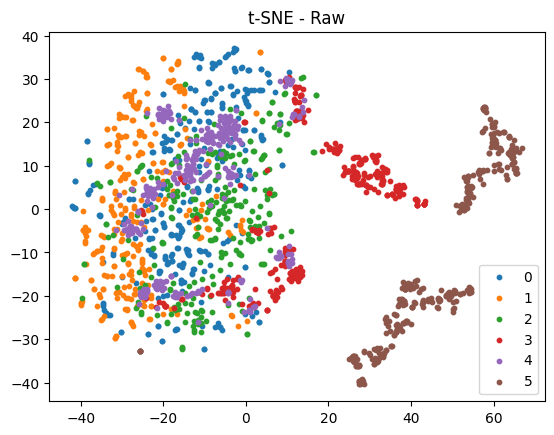

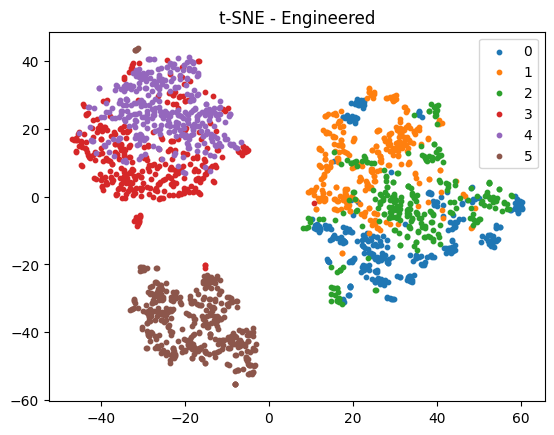

In [9]:
from sklearn.manifold import TSNE

def plot_tsne(X, y, title="t-SNE"):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X)

    plt.figure()
    for label in np.unique(y):
        idx = y == label
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, s=10)

    plt.legend()
    plt.title(title)
    plt.show()

# Use subset (t-SNE is slow)
idx = np.random.choice(len(X_train_feat), 2000, replace=False)

plot_tsne(X_train_flat[idx], y_train[idx], title="t-SNE - Raw")
plot_tsne(X_train_feat[idx], y_train[idx], title="t-SNE - Engineered")

## Train and Evaluate Model

In [10]:
label_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

In [11]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names, digits=4))
    print("Confusion Matrix:")
    print(cm)

    return {
        "name": name,
        "model": model,
        "accuracy": acc,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }

### Decision Tree

In [12]:
dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [13]:
nb_model = GaussianNB()

In [14]:
svm_rbf_model = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    random_state=42
)

In [15]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=6,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [16]:
results = []

results.append(
    evaluate_model(
        "Decision Tree",
        dt_model,
        X_train_feat, y_train,
        X_test_feat, y_test
    )
)

results.append(
    evaluate_model(
        "Gaussian Naive Bayes",
        nb_model,
        X_train_feat, y_train,
        X_test_feat, y_test
    )
)

results.append(
    evaluate_model(
        "SVM (RBF)",
        svm_rbf_model,
        X_train_feat, y_train,
        X_test_feat, y_test
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        xgb_model,
        X_train_feat, y_train,
        X_test_feat, y_test
    )
)


Decision Tree
Accuracy: 0.8388

Classification Report:
                    precision    recall  f1-score   support

           WALKING     0.8023    0.8589    0.8296       496
  WALKING_UPSTAIRS     0.7692    0.7643    0.7668       471
WALKING_DOWNSTAIRS     0.8454    0.7810    0.8119       420
           SITTING     0.8499    0.7149    0.7765       491
          STANDING     0.7705    0.8835    0.8231       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.8388      2947
         macro avg     0.8395    0.8337    0.8347      2947
      weighted avg     0.8414    0.8388    0.8381      2947

Confusion Matrix:
[[426  40  30   0   0   0]
 [ 81 360  30   0   0   0]
 [ 24  68 328   0   0   0]
 [  0   0   0 351 140   0]
 [  0   0   0  62 470   0]
 [  0   0   0   0   0 537]]

Gaussian Naive Bayes
Accuracy: 0.7995

Classification Report:
                    precision    recall  f1-score   support

           WALKING     0.8371    0.7

In [17]:
print("\nFinal ranking:")
results = sorted(results, key=lambda x: x["accuracy"], reverse=True)

for r in results:
    print(f"{r['name']:20s} -> Accuracy: {r['accuracy']:.4f}")


Final ranking:
XGBoost              -> Accuracy: 0.9179
SVM (RBF)            -> Accuracy: 0.9026
Decision Tree        -> Accuracy: 0.8388
Gaussian Naive Bayes -> Accuracy: 0.7995
